/tmp/ipykernel_2637/2886005401.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv('sales data-set.csv')


Revenue: 2451879177.46
Orders: 134761
AOV: 18194.278592916347
Dept
38    1.510379e+08
95    1.421005e+08
92    1.415266e+08
72    1.149110e+08
40    1.100530e+08
Name: Weekly_Sales, dtype: float64
Type
A    22715.067373
B    11967.307567
Name: Weekly_Sales, dtype: float64


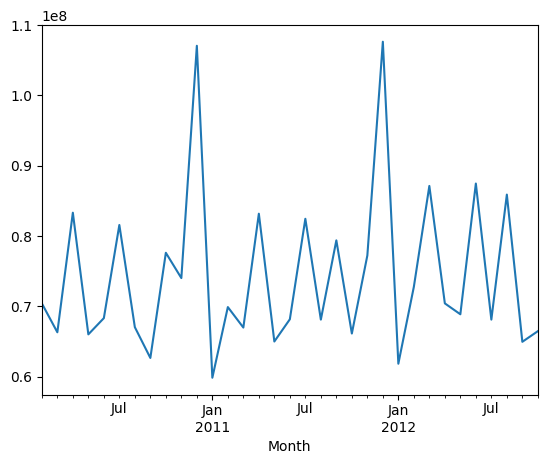

In [2]:
import pandas as pd

# Load
sales = pd.read_csv('sales data-set.csv')
stores = pd.read_csv('stores data-set.csv')
features = pd.read_csv('Features data set.csv')

# Task 1: Combine - use only Store for safety
df = pd.merge(sales, stores, on='Store', how='left')
df = pd.merge(df, features, on=['Store','Date'], how='left')

# Task 2: Clean
df.drop_duplicates(inplace=True)
df.fillna(0, inplace=True)

# Task 3: KPIs
revenue = df['Weekly_Sales'].sum()
orders = len(df)
aov = revenue / orders
print(f"Revenue: {revenue}")
print(f"Orders: {orders}")
print(f"AOV: {aov}")

# Task 4: Monthly Trend - FIXED LINE HERE
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.to_period('M')
df.groupby('Month')['Weekly_Sales'].sum().plot()

# Task 5: Top Products & Regional
print(df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(5))
print(df.groupby('Type')['Weekly_Sales'].mean())